#  SHAP Analysis for Clinical Model Interpretability
## Thyroid Cancer Recurrence Prediction

---

This notebook performs **SHAP (SHapley Additive exPlanations)** analysis predict thyroid cancer recurrence.

### Objectives
- Apply KernelSHAP to explain the black-box ensemble
- Derive **global feature importance** rankings
- Generate **individual patient-level explanations**
- Produce clinically interpretable outputs for decision support



---
## 1. Imports & Environment Setup



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
output_folder = os.path.join(project_root, "results", "SHAP_Analysis_Outputs")
os.makedirs(output_folder, exist_ok=True)

print(f"Current directory: {current_dir}")
print(f"Output folder: {output_folder}")
print(" SHAP ANALYSIS FOR CLINICAL MODEL INTERPRETABILITY")

Current directory: d:\DataScience Assignments\Project\Thyroid-Cancer-Recurrence-Prediction-Project\code base
Output folder: d:\DataScience Assignments\Project\Thyroid-Cancer-Recurrence-Prediction-Project\results\SHAP_Analysis_Outputs
 SHAP ANALYSIS FOR CLINICAL MODEL INTERPRETABILITY


---
## 2. Load Dataset

Read the thyroid differentiated cancer dataset and separate features from the target variable (`Recurred`).



In [4]:
data = pd.read_csv("Thyroid_Diff.csv")
X = data.drop("Recurred", axis=1)
y = data["Recurred"].map({"No": 0, "Yes": 1})

print(" DATA LOADED")
print(f"Total samples      : {len(data)}")
print(f"Recurrence (1)     : {sum(y==1)}")
print(f"Non-recurrence (0) : {sum(y==0)}")
print(f"Features           : {list(X.columns)}")

 DATA LOADED
Total samples      : 383
Recurrence (1)     : 108
Non-recurrence (0) : 275
Features           : ['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response']


---
## 3. Encode Categorical Variables



In [5]:
X_encoded = pd.get_dummies(X, drop_first=False)

print(f"Original features : {X.shape[1]}")
print(f"Encoded features  : {X_encoded.shape[1]}")

Original features : 16
Encoded features  : 55


---
## 4. Train / Test Split

Split the dataset into **75% training** and **25% test** sets.



In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    train_size=0.75,
    random_state=321,
    stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 287
Test samples     : 96


---
## 5. Feature Scaling



In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(" Data scaled using StandardScaler")
print(f"Training shape : {X_train_scaled.shape}")
print(f"Test shape     : {X_test_scaled.shape}")

 Data scaled using StandardScaler
Training shape : (287, 55)
Test shape     : (96, 55)


---
## 6. Build & Train Heterogeneous Stacking Ensemble





In [9]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LogisticRegression as LR
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline

print(" BUILDING STACKING ENSEMBLE")

try:
    from umap import UMAP
    umap_available = True
    print(" UMAP available — using non-linear dimensionality reduction")
except ImportError:
    umap_available = False
    print("  UMAP not available — using PCA as fallback")

# --- Pipeline 1: PCA + Logistic Regression ---
pca = PCA(n_components=5)
lr_pca = LR(C=0.36, penalty='l1', solver='liblinear',
            class_weight='balanced', random_state=42, max_iter=1000)
pipeline_lr_pca = Pipeline([('pca', pca), ('clf', lr_pca)])

# --- Pipeline 2: TruncatedSVD + SVM ---
tsvd = TruncatedSVD(n_components=5)
svm_tsvd = SVC(probability=True, C=0.25, kernel='sigmoid',
               class_weight='balanced', random_state=42)
pipeline_svm_tsvd = Pipeline([('tsvd', tsvd), ('clf', svm_tsvd)])

# --- Pipeline 3: UMAP/PCA + Random Forest ---
if umap_available:
    umap_reducer = UMAP(n_components=5, random_state=42, n_neighbors=15, min_dist=0.1)
    rf_model = RF(criterion='entropy', max_depth=None, max_features='log2',
                  min_samples_leaf=4, n_estimators=200,
                  class_weight='balanced', random_state=42)
    pipeline_rf = Pipeline([('umap', umap_reducer), ('clf', rf_model)])
else:
    pca_rf = PCA(n_components=5)
    rf_model = RF(criterion='entropy', max_depth=None, max_features='log2',
                  min_samples_leaf=4, n_estimators=200,
                  class_weight='balanced', random_state=42)
    pipeline_rf = Pipeline([('pca', pca_rf), ('clf', rf_model)])

# --- Stacking Ensemble ---
ensemble_model = StackingClassifier(
    estimators=[
        ('lr_pca',   pipeline_lr_pca),
        ('svm_tsvd', pipeline_svm_tsvd),
        ('rf',       pipeline_rf)
    ],
    final_estimator=LR(C=0.1, class_weight='balanced', random_state=42),
    cv=3,
    stack_method='predict_proba',
    n_jobs=1
)

print(" Training stacking ensemble...")
ensemble_model.fit(X_train_scaled, y_train)

from sklearn.metrics import balanced_accuracy_score
y_pred = ensemble_model.predict(X_test_scaled)
test_bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\n Ensemble Model Test Balanced Accuracy: {test_bal_acc:.4f}")

 BUILDING STACKING ENSEMBLE
 UMAP available — using non-linear dimensionality reduction
 Training stacking ensemble...

 Ensemble Model Test Balanced Accuracy: 0.9412


---
## 7. SHAP Analysis — KernelExplainer

**KernelSHAP** is used because the stacking ensemble is a black-box model with no tree structure.  
It approximates Shapley values by fitting a weighted linear model around the prediction function.

| Parameter | Value | Rationale |
|---|---|---|
| Background samples | 30 | Representative summary of training distribution |
| Explanation samples | 50 | Test instances to explain |
| `nsamples` | 50 | SHAP perturbation samples per instance |



In [10]:
import shap

print(" SHAP ANALYSIS: HETEROGENEOUS STACKING ENSEMBLE\n")

feature_names = X_encoded.columns.tolist()

def predict_proba_wrapper(X_scaled):
    return ensemble_model.predict_proba(X_scaled)

background_size = min(30, len(X_train_scaled))
explain_size    = min(50, len(X_test_scaled))

background_sample = X_train_scaled[
    np.random.choice(len(X_train_scaled), background_size, replace=False)
]
explain_sample = X_test_scaled[
    np.random.choice(len(X_test_scaled), explain_size, replace=False)
]

print(f"Background samples  : {background_sample.shape[0]}")
print(f"Explanation samples : {explain_sample.shape[0]}")
print(" Creating SHAP explainer (may take 2–3 minutes)...")

explainer = shap.KernelExplainer(predict_proba_wrapper, background_sample)

print(" Calculating SHAP values...")
shap_values = explainer.shap_values(explain_sample, nsamples=50)

print(" SHAP analysis complete!")

# Extract SHAP values for class 1 (Recurrence)
if len(shap_values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

 SHAP ANALYSIS: HETEROGENEOUS STACKING ENSEMBLE

Background samples  : 30
Explanation samples : 50
 Creating SHAP explainer (may take 2–3 minutes)...
 Calculating SHAP values...


  0%|          | 0/50 [00:00<?, ?it/s]

 SHAP analysis complete!


---
## 8. Global Feature Importance

Compute **mean absolute SHAP values** across all explanation samples to rank features by their average contribution to model predictions.

Two visualisations are generated:
1. **Bar chart** — magnitude of influence (top 15 features)
2. **Beeswarm plot** — direction and distribution of impact per feature

 GLOBAL FEATURE IMPORTANCE

Top 15 Most Influential Features:
-------------------------------------------------------
  Response_Structural Incomplete          : 0.0261
  N_N1b                                   : 0.0223
  Risk_Low                                : 0.0206
  N_N0                                    : 0.0192
  Adenopathy_No                           : 0.0186
  Adenopathy_Bilateral                    : 0.0138
  Response_Excellent                      : 0.0102
  Focality_Multi-Focal                    : 0.0100
  Stage_II                                : 0.0100
  Risk_Intermediate                       : 0.0099
  Focality_Uni-Focal                      : 0.0077
  Gender_M                                : 0.0076
  Smoking_No                              : 0.0071
  T_T1a                                   : 0.0069
  Pathology_Micropapillary                : 0.0068


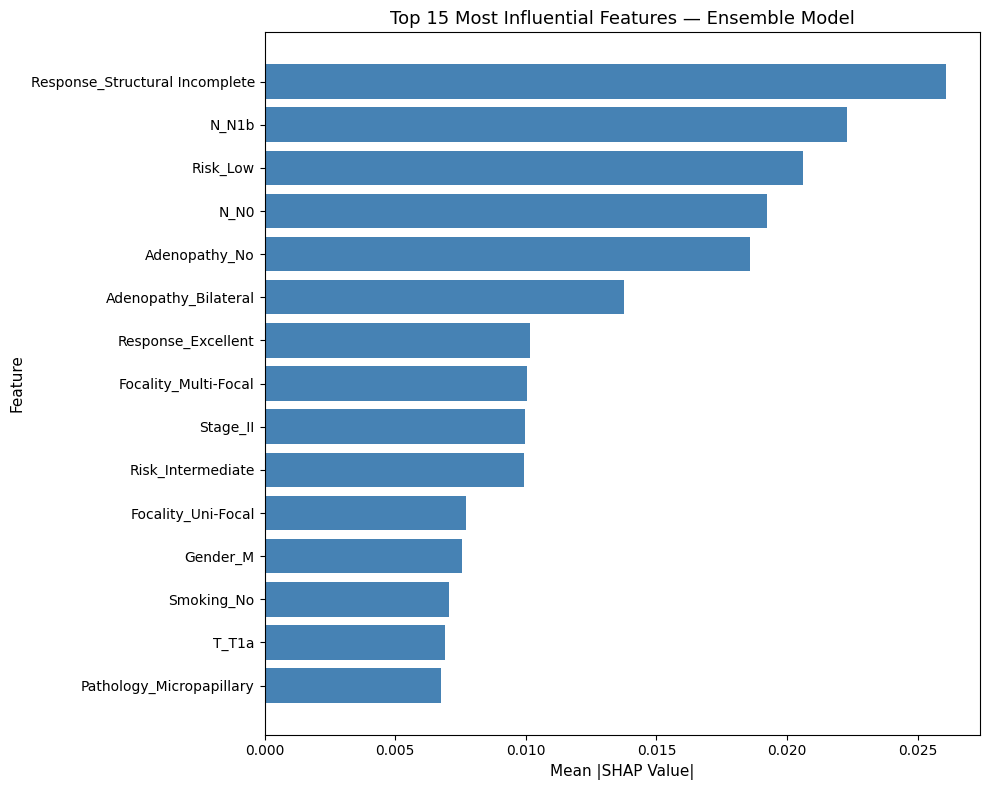

[SAVED] shap_ensemble_global_importance.png


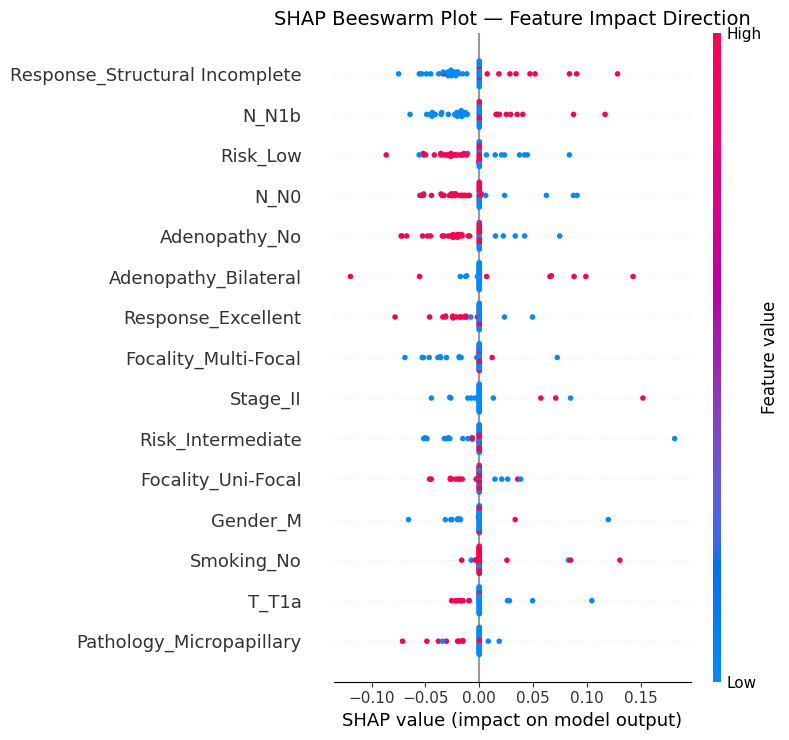

[SAVED] shap_ensemble_beeswarm.png


In [11]:
print(" GLOBAL FEATURE IMPORTANCE\n")

mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP_Value': mean_abs_shap
}).sort_values('Mean_SHAP_Value', ascending=False)

print("Top 15 Most Influential Features:")
print("-" * 55)
for i, row in feature_importance.head(15).iterrows():
    feat = row['Feature'][:40] if len(row['Feature']) > 40 else row['Feature']
    print(f"  {feat:<40}: {row['Mean_SHAP_Value']:.4f}")

# --- Bar Chart ---
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'], top_features['Mean_SHAP_Value'], color='steelblue')
plt.xlabel('Mean |SHAP Value|', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title('Top 15 Most Influential Features — Ensemble Model', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "shap_ensemble_global_importance.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_ensemble_global_importance.png")

# --- Beeswarm Plot ---
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_class1, explain_sample,
                  feature_names=feature_names, plot_type="dot",
                  max_display=15, show=False)
plt.title("SHAP Beeswarm Plot — Feature Impact Direction", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "shap_ensemble_beeswarm.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_ensemble_beeswarm.png")

---
## 9. Save Feature Importance to CSV

Export the ranked feature importance table for downstream analysis or reporting.

In [12]:
feature_importance.to_csv(
    os.path.join(output_folder, "shap_feature_importance_ensemble.csv"),
    index=False
)
print("[SAVED] shap_feature_importance_ensemble.csv")
feature_importance.head(10)

[SAVED] shap_feature_importance_ensemble.csv


,Feature,Mean_SHAP_Value
54,Response_Structural Incomplete,0.026084
43,N_N1b,0.022302
33,Risk_Low,0.020605
41,N_N0,0.019243
22,Adenopathy_No,0.018580
19,Adenopathy_Bilateral,0.013760
52,Response_Excellent,0.010151
29,Focality_Multi-Focal,0.010045
47,Stage_II,0.009959
32,Risk_Intermediate,0.009915


---
## 10. Individual Patient Explanations

SHAP enables **local (instance-level) explanations** — showing which features pushed the model toward or away from a recurrence prediction for a specific patient.

Two patients are selected from the test set:
-  **Recurrence patient** — actual label = 1
-  **Non-recurrence patient** — actual label = 0

For each patient, the top features driving the prediction are identified.

👤 INDIVIDUAL PATIENT EXPLANATIONS

 RECURRENCE PATIENT (Actual: Recurrence)
   Predicted recurrence probability : 0.8838

 NON-RECURRENCE PATIENT (Actual: No Recurrence)
   Predicted recurrence probability : 0.2464


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


  Debug Info:
    SHAP values shape  : (55,)
    Features count     : 55
    Expected value type: <class 'numpy.float64'>

[SAVED] patient_shap_values.csv

  🔺 TOP 5 FEATURES PUSHING TOWARD RECURRENCE:
    T_T4a: +0.1333
    T_T3a: +0.0585
    Smoking_No: +0.0582
    M_M1: +0.0549
    Stage_IVB: +0.0466

  🔻 TOP 5 FEATURES PUSHING AWAY FROM RECURRENCE:
    Physical Examination_Multinodular goiter: -0.0354


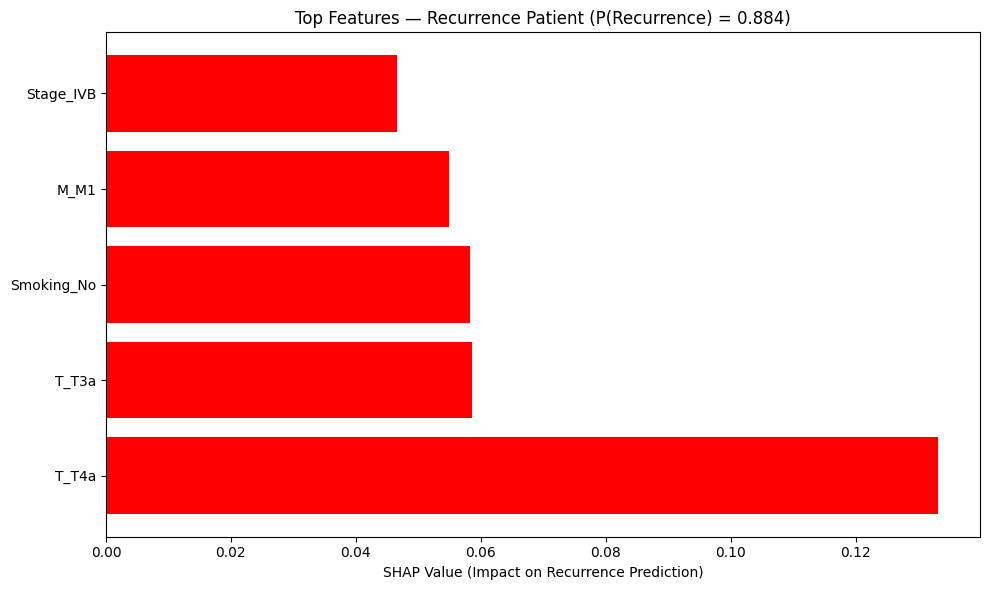

[SAVED] shap_recurrence_patient_top_features.png
[SAVED] patient_predictions.csv


In [13]:
print("👤 INDIVIDUAL PATIENT EXPLANATIONS\n")

y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
recurrence_indices     = np.where(y_test_array == 1)[0]
non_recurrence_indices = np.where(y_test_array == 0)[0]

if len(recurrence_indices) > 0 and len(non_recurrence_indices) > 0:
    recurrence_idx     = recurrence_indices[0]
    non_recurrence_idx = non_recurrence_indices[0]

    recurrence_patient     = X_test_scaled[recurrence_idx:recurrence_idx+1]
    non_recurrence_patient = X_test_scaled[non_recurrence_idx:non_recurrence_idx+1]

    pred_recurrence     = ensemble_model.predict_proba(recurrence_patient)[0, 1]
    pred_non_recurrence = ensemble_model.predict_proba(non_recurrence_patient)[0, 1]

    print(f" RECURRENCE PATIENT (Actual: Recurrence)")
    print(f"   Predicted recurrence probability : {pred_recurrence:.4f}")
    print(f"\n NON-RECURRENCE PATIENT (Actual: No Recurrence)")
    print(f"   Predicted recurrence probability : {pred_non_recurrence:.4f}")

    shap_recurrence     = explainer.shap_values(recurrence_patient, nsamples=50)
    shap_non_recurrence = explainer.shap_values(non_recurrence_patient, nsamples=50)

    if len(shap_recurrence.shape) == 3:
        shap_rec_class1 = shap_recurrence[0, :, 1].flatten()
        shap_non_class1 = shap_non_recurrence[0, :, 1].flatten()
    elif len(shap_recurrence.shape) == 2:
        shap_rec_class1 = shap_recurrence[0].flatten()
        shap_non_class1 = shap_non_recurrence[0].flatten()
    else:
        shap_rec_class1 = shap_recurrence.flatten()
        shap_non_class1 = shap_non_recurrence.flatten()

    if isinstance(explainer.expected_value, list):
        expected_value = explainer.expected_value[1]
    elif hasattr(explainer.expected_value, '__len__') and len(explainer.expected_value) > 1:
        expected_value = explainer.expected_value[1]
    else:
        expected_value = explainer.expected_value

    print(f"\n  Debug Info:")
    print(f"    SHAP values shape  : {shap_rec_class1.shape}")
    print(f"    Features count     : {len(feature_names)}")
    print(f"    Expected value type: {type(expected_value)}")

    # Save patient SHAP values
    shap_patient_df = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Recurrence_Patient':    shap_rec_class1,
        'SHAP_NonRecurrence_Patient': shap_non_class1
    })
    shap_patient_df.to_csv(os.path.join(output_folder, "patient_shap_values.csv"), index=False)
    print("\n[SAVED] patient_shap_values.csv")

    # Top drivers
    top_positive_idx = np.argsort(shap_rec_class1)[-5:][::-1]
    top_negative_idx = np.argsort(shap_rec_class1)[:5]

    print("\n  🔺 TOP 5 FEATURES PUSHING TOWARD RECURRENCE:")
    for idx in top_positive_idx:
        if shap_rec_class1[idx] > 0:
            print(f"    {feature_names[idx][:45]}: +{shap_rec_class1[idx]:.4f}")

    print("\n  🔻 TOP 5 FEATURES PUSHING AWAY FROM RECURRENCE:")
    for idx in top_negative_idx:
        if shap_rec_class1[idx] < 0:
            print(f"    {feature_names[idx][:45]}: {shap_rec_class1[idx]:.4f}")

    # Patient feature bar chart
    try:
        plt.figure(figsize=(10, 6))
        top_features_idx = top_positive_idx[:5]
        top_values = shap_rec_class1[top_features_idx]
        top_names  = [feature_names[i][:35] for i in top_features_idx]
        colors = ['red' if v > 0 else 'green' for v in top_values]
        plt.barh(top_names, top_values, color=colors)
        plt.xlabel('SHAP Value (Impact on Recurrence Prediction)')
        plt.title(f'Top Features — Recurrence Patient (P(Recurrence) = {pred_recurrence:.3f})')
        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, "shap_recurrence_patient_top_features.png"),
                    dpi=150, bbox_inches='tight')
        plt.show()
        print("[SAVED] shap_recurrence_patient_top_features.png")
    except Exception as e:
        print(f"    Could not generate plot: {e}")

    # Save patient summary
    patient_summary = pd.DataFrame({
        'Patient_Type':          ['Recurrence', 'Non-Recurrence'],
        'Prediction_Probability': [pred_recurrence, pred_non_recurrence],
        'Actual_Class':          [1, 0]
    })
    patient_summary.to_csv(os.path.join(output_folder, "patient_predictions.csv"), index=False)
    print("[SAVED] patient_predictions.csv")
else:
    print("  Insufficient samples for patient-level explanations")

---
## 11. Clinical Interpretation Summary

Synthesise findings from the SHAP analysis into actionable clinical insights.

In [14]:
print(" CLINICAL INTERPRETATION SUMMARY")
print("=" * 50)
print("""
KEY CLINICAL INSIGHTS FROM SHAP ANALYSIS:
-----------------------------------------

1. TOP PREDICTORS ALIGN WITH CLINICAL KNOWLEDGE:
   - Response to treatment (Structural Incomplete, Excellent)
   - Risk category (Low, High)
   - N stage (N1b)
   - Adenopathy (No, Bilateral)

2. MODEL BEHAVIOUR IS CLINICALLY SENSIBLE:
   - Structural Incomplete response → pushes toward recurrence
   - Excellent response            → pushes away from recurrence
   - High risk + N1b stage         → positively correlate with recurrence

3. SHAP TRANSPARENCY ENABLES CLINICIANS TO:
   - Verify model decisions align with medical guidelines
   - Identify which features drive each patient's prediction
   - Build trust in AI-assisted clinical decision making
""")

print("=" * 50)
print(" SHAP ANALYSIS COMPLETE")
print(f" All outputs saved to: {output_folder}")

 CLINICAL INTERPRETATION SUMMARY

KEY CLINICAL INSIGHTS FROM SHAP ANALYSIS:
-----------------------------------------

1. TOP PREDICTORS ALIGN WITH CLINICAL KNOWLEDGE:
   - Response to treatment (Structural Incomplete, Excellent)
   - Risk category (Low, High)
   - N stage (N1b)
   - Adenopathy (No, Bilateral)

2. MODEL BEHAVIOUR IS CLINICALLY SENSIBLE:
   - Structural Incomplete response → pushes toward recurrence
   - Excellent response            → pushes away from recurrence
   - High risk + N1b stage         → positively correlate with recurrence

3. SHAP TRANSPARENCY ENABLES CLINICIANS TO:
   - Verify model decisions align with medical guidelines
   - Identify which features drive each patient's prediction
   - Build trust in AI-assisted clinical decision making

 SHAP ANALYSIS COMPLETE
 All outputs saved to: d:\DataScience Assignments\Project\Thyroid-Cancer-Recurrence-Prediction-Project\results\SHAP_Analysis_Outputs



SHAP ANALYSIS: COST-SENSITIVE MODEL (1.2x FN Penalty)
Training cost-sensitive ensemble (1.2x FN penalty)...

Cost-Sensitive Model Test Balanced Accuracy: 0.9259

Creating SHAP explainer for cost-sensitive model...
Calculating SHAP values...


  0%|          | 0/50 [00:00<?, ?it/s]


Top 10 Features (Cost-Sensitive Model):
-------------------------------------------------------
  Response_Structural Incomplete               : 0.0356
  Adenopathy_No                                : 0.0219
  N_N0                                         : 0.0187
  N_N1b                                        : 0.0174
  Response_Excellent                           : 0.0147
  Risk_Low                                     : 0.0128
  Adenopathy_Left                              : 0.0102
  Adenopathy_Bilateral                         : 0.0096
  Adenopathy_Right                             : 0.0091
  Physical Examination_Multinodular goiter     : 0.0085

COMPARISON: Ensemble vs Cost-Sensitive Model

Top 5 Features with Increased Importance after Cost-Sensitivity:
-------------------------------------------------------
  Response_Structural Incomplete               : +0.0095
  Adenopathy_Left                              : +0.0078
  Response_Indeterminate                       : +0.0059
  Re

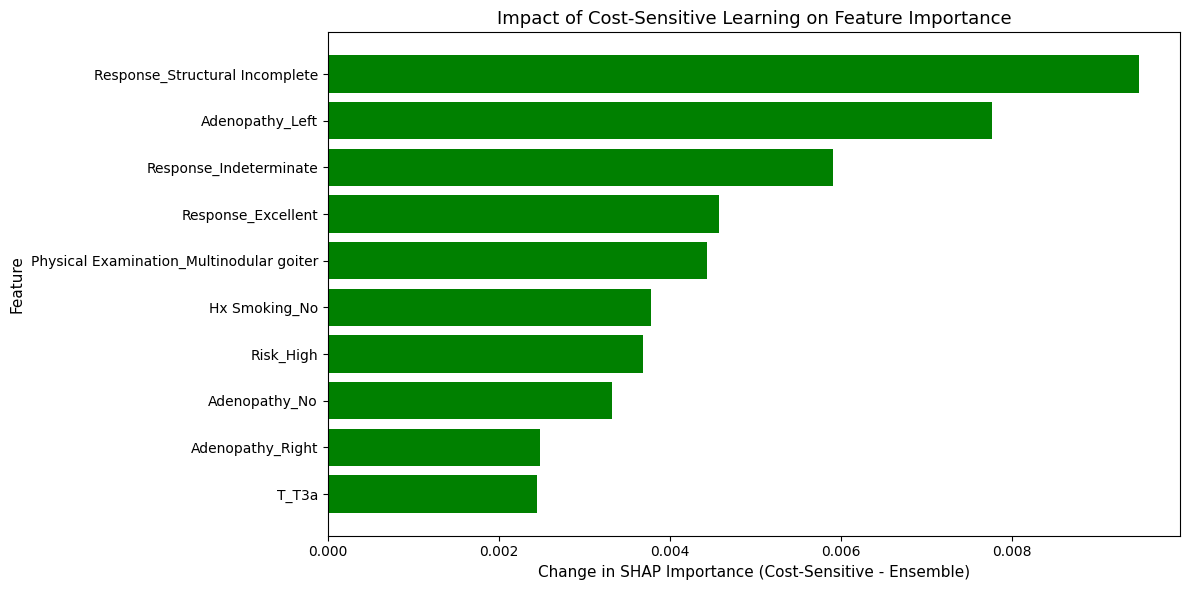

[SAVED] cost_sensitive_shap_comparison.png


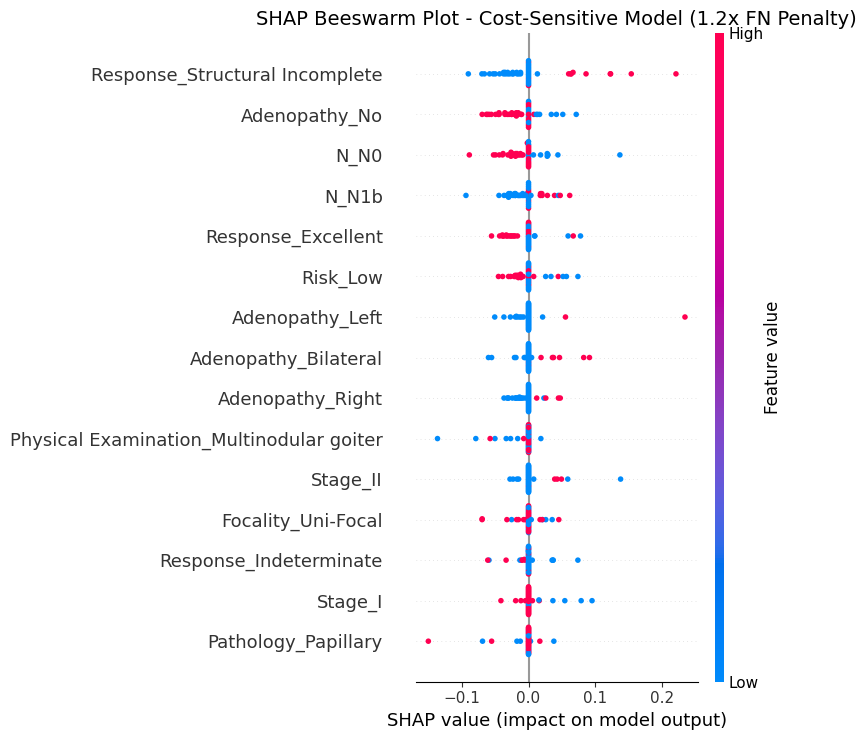

[SAVED] shap_cost_sensitive_beeswarm.png

COST-SENSITIVE SHAP ANALYSIS COMPLETE


In [15]:
# =============================================================================
# CELL 12: SHAP ANALYSIS ON COST-SENSITIVE MODEL (Improvisation #2)
# =============================================================================

print("\n" + "=" * 60)
print("SHAP ANALYSIS: COST-SENSITIVE MODEL (1.2x FN Penalty)")
print("=" * 60)

# Import required modules (in case they are not in memory)
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Use full name or alias
LR = LogisticRegression
RF = RandomForestClassifier

# Define cost-sensitive weights (1.2x FN penalty)
cost_sensitive_weights = {0: 1.0, 1: 1.2}

# Check UMAP availability
try:
    from umap import UMAP
    umap_available = True
except ImportError:
    umap_available = False
    print("UMAP not available - using PCA as fallback")

# =========================================================================
# Base Learner 1: PCA + Logistic Regression (cost-sensitive)
# =========================================================================
pca_lr_cs = LogisticRegression(C=0.36, penalty='l1', solver='liblinear', 
                               class_weight=cost_sensitive_weights, 
                               random_state=42, max_iter=1000)
pipeline_lr_pca_cs = Pipeline([('pca', PCA(n_components=5)), ('clf', pca_lr_cs)])

# =========================================================================
# Base Learner 2: t-SVD + SVM (cost-sensitive)
# =========================================================================
svm_tsvd_cs = SVC(probability=True, C=0.25, kernel='sigmoid', 
                  class_weight=cost_sensitive_weights, random_state=42)
pipeline_svm_tsvd_cs = Pipeline([('tsvd', TruncatedSVD(n_components=5)), ('clf', svm_tsvd_cs)])

# =========================================================================
# Base Learner 3: UMAP/PCA + Random Forest (cost-sensitive)
# =========================================================================
if umap_available:
    rf_model_cs = RandomForestClassifier(criterion='entropy', max_depth=None, 
                                         max_features='log2',
                                         min_samples_leaf=4, n_estimators=200, 
                                         class_weight=cost_sensitive_weights, 
                                         random_state=42)
    pipeline_rf_cs = Pipeline([('umap', UMAP(n_components=5, random_state=42, 
                                             n_neighbors=15, min_dist=0.1)), 
                               ('clf', rf_model_cs)])
else:
    rf_model_cs = RandomForestClassifier(criterion='entropy', max_depth=None, 
                                         max_features='log2',
                                         min_samples_leaf=4, n_estimators=200, 
                                         class_weight=cost_sensitive_weights, 
                                         random_state=42)
    pipeline_rf_cs = Pipeline([('pca', PCA(n_components=5)), ('clf', rf_model_cs)])

# =========================================================================
# Meta-learner (cost-sensitive)
# =========================================================================
meta_learner_cs = LogisticRegression(C=0.1, class_weight=cost_sensitive_weights, 
                                     random_state=42)

# =========================================================================
# Cost-sensitive stacking ensemble
# =========================================================================
cost_sensitive_model = StackingClassifier(
    estimators=[
        ('lr_pca', pipeline_lr_pca_cs),
        ('svm_tsvd', pipeline_svm_tsvd_cs),
        ('rf', pipeline_rf_cs)
    ],
    final_estimator=meta_learner_cs,
    cv=3,
    stack_method='predict_proba',
    n_jobs=1
)

# =========================================================================
# Train cost-sensitive model
# =========================================================================
print("Training cost-sensitive ensemble (1.2x FN penalty)...")
cost_sensitive_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_cs = cost_sensitive_model.predict(X_test_scaled)
test_bal_acc_cs = balanced_accuracy_score(y_test, y_pred_cs)
print(f"\nCost-Sensitive Model Test Balanced Accuracy: {test_bal_acc_cs:.4f}")
print("=" * 60)

# =========================================================================
# SHAP for cost-sensitive model
# =========================================================================
def predict_proba_cs(X_scaled):
    return cost_sensitive_model.predict_proba(X_scaled)

print("\nCreating SHAP explainer for cost-sensitive model...")
explainer_cs = shap.KernelExplainer(predict_proba_cs, background_sample)

print("Calculating SHAP values...")
shap_values_cs = explainer_cs.shap_values(explain_sample, nsamples=50)

# Extract for class 1
if len(shap_values_cs.shape) == 3:
    shap_values_class1_cs = shap_values_cs[:, :, 1]
else:
    shap_values_class1_cs = shap_values_cs

# =========================================================================
# Feature importance for cost-sensitive model
# =========================================================================
mean_abs_shap_cs = np.abs(shap_values_class1_cs).mean(axis=0)
feature_importance_cs = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP_Value_CS': mean_abs_shap_cs
}).sort_values('Mean_SHAP_Value_CS', ascending=False)

print("\nTop 10 Features (Cost-Sensitive Model):")
print("-" * 55)
for i, row in feature_importance_cs.head(10).iterrows():
    feature_display = row['Feature'][:45] if len(row['Feature']) > 45 else row['Feature']
    print(f"  {feature_display:<45}: {row['Mean_SHAP_Value_CS']:.4f}")

# =========================================================================
# Compare feature importance between models
# =========================================================================
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Ensemble_SHAP': mean_abs_shap,
    'CostSensitive_SHAP': mean_abs_shap_cs,
    'Difference': mean_abs_shap_cs - mean_abs_shap
}).sort_values('Difference', ascending=False)

print("\n" + "=" * 60)
print("COMPARISON: Ensemble vs Cost-Sensitive Model")
print("=" * 60)
print("\nTop 5 Features with Increased Importance after Cost-Sensitivity:")
print("-" * 55)
for i, row in comparison_df.head(5).iterrows():
    feature_display = row['Feature'][:45] if len(row['Feature']) > 45 else row['Feature']
    print(f"  {feature_display:<45}: +{row['Difference']:.4f}")

print("\nTop 5 Features with Decreased Importance after Cost-Sensitivity:")
for i, row in comparison_df.tail(5).iterrows():
    if row['Difference'] < 0:
        feature_display = row['Feature'][:45] if len(row['Feature']) > 45 else row['Feature']
        print(f"  {feature_display:<45}: {row['Difference']:.4f}")

# =========================================================================
# Save comparison
# =========================================================================
comparison_df.to_csv(os.path.join(output_folder, "model_comparison_shap.csv"), index=False)
print(f"\n[SAVED] model_comparison_shap.csv")

# =========================================================================
# Bar plot comparison
# =========================================================================
plt.figure(figsize=(12, 6))
top_compare = comparison_df.head(10)
colors = ['green' if x > 0 else 'red' for x in top_compare['Difference']]
plt.barh(top_compare['Feature'], top_compare['Difference'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Change in SHAP Importance (Cost-Sensitive - Ensemble)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title('Impact of Cost-Sensitive Learning on Feature Importance', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "cost_sensitive_shap_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"[SAVED] cost_sensitive_shap_comparison.png")

# =========================================================================
# Beeswarm plot for cost-sensitive model
# =========================================================================
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_class1_cs, explain_sample, feature_names=feature_names, 
                  plot_type="dot", max_display=15, show=False)
plt.title("SHAP Beeswarm Plot - Cost-Sensitive Model (1.2x FN Penalty)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "shap_cost_sensitive_beeswarm.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"[SAVED] shap_cost_sensitive_beeswarm.png")

print("\n" + "=" * 60)
print("COST-SENSITIVE SHAP ANALYSIS COMPLETE")
print("=" * 60)